# 1... Importing data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
# data = pd.read_csv('final_df.csv')
# data = pd.read_csv('Oversampled_df.csv')
data = pd.read_csv('downsampled_df.csv')
data.set_index('date', inplace=True)
data.head()

,Close_^DJI,Close_^FCHI,Close_^FTSE,Close_^GDAXI,Close_^GSPTSE,Close_^HSI,Close_^IXIC,Close_^N225,Volume_^DJI,Volume_^FCHI,...,WBAA_pct_change,DPSACBW027SBOG_pct_change,WCOILWTICO_pct_change,WGS30YR_pct_change,WRESBAL_pct_change,WGS20YR_pct_change,MORTGAGE15US_pct_change,WPRIME_pct_change,CCSA_pct_change,TOTCI_pct_change
date,,,,,,,,,,,,,,,,,,,,,
1996-04-08,5594.370117,2075.000000,3755.600098,2498.750000,5004.000000,11139.900391,1105.660034,21424.240234,39940000.0,0.0,...,0.370828,0.353936,2.088062,0.451128,-4.127706,0.587372,1.390821,0.000000,-1.009346,0.205264
1996-07-15,5349.509766,2029.500000,3698.300049,2529.500000,4955.299805,10800.099609,1060.189941,21753.419922,43110000.0,0.0,...,1.323706,0.332418,1.168224,1.571429,-12.521018,1.544944,3.389831,0.000000,-0.239904,-0.081856
1997-03-31,6583.479980,2656.699951,4312.899902,3407.830078,5850.200195,12534.299805,1221.699951,18003.400391,63290000.0,0.0,...,0.243309,0.707266,-4.097606,0.430416,24.514974,0.282087,0.402685,0.484848,0.387597,0.485023
1997-06-23,7604.299805,2762.199951,4575.799805,3748.790039,6437.700195,15021.200195,1434.319946,20436.140625,49260000.0,0.0,...,-1.488834,-0.068937,0.264831,-1.617647,33.381106,-1.601164,-1.788171,0.000000,1.677704,0.085288
1997-10-27,7161.200195,2769.600098,4840.700195,3871.389893,6599.200195,10498.200195,1532.750000,17038.359375,91830000.0,0.0,...,-0.786370,-0.661751,-0.142653,-0.312500,11.277218,-0.309598,0.145138,0.000000,2.108158,-0.428803


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 258 entries, 1996-04-08 to 2015-02-02
Data columns (total 85 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Close_^DJI                 258 non-null    float64
 1   Close_^FCHI                258 non-null    float64
 2   Close_^FTSE                258 non-null    float64
 3   Close_^GDAXI               258 non-null    float64
 4   Close_^GSPTSE              258 non-null    float64
 5   Close_^HSI                 258 non-null    float64
 6   Close_^IXIC                258 non-null    float64
 7   Close_^N225                258 non-null    float64
 8   Volume_^DJI                258 non-null    float64
 9   Volume_^FCHI               258 non-null    float64
 10  Volume_^FTSE               258 non-null    float64
 11  Volume_^GDAXI              258 non-null    float64
 12  Volume_^GSPTSE             258 non-null    float64
 13  Volume_^HSI                258 non-null

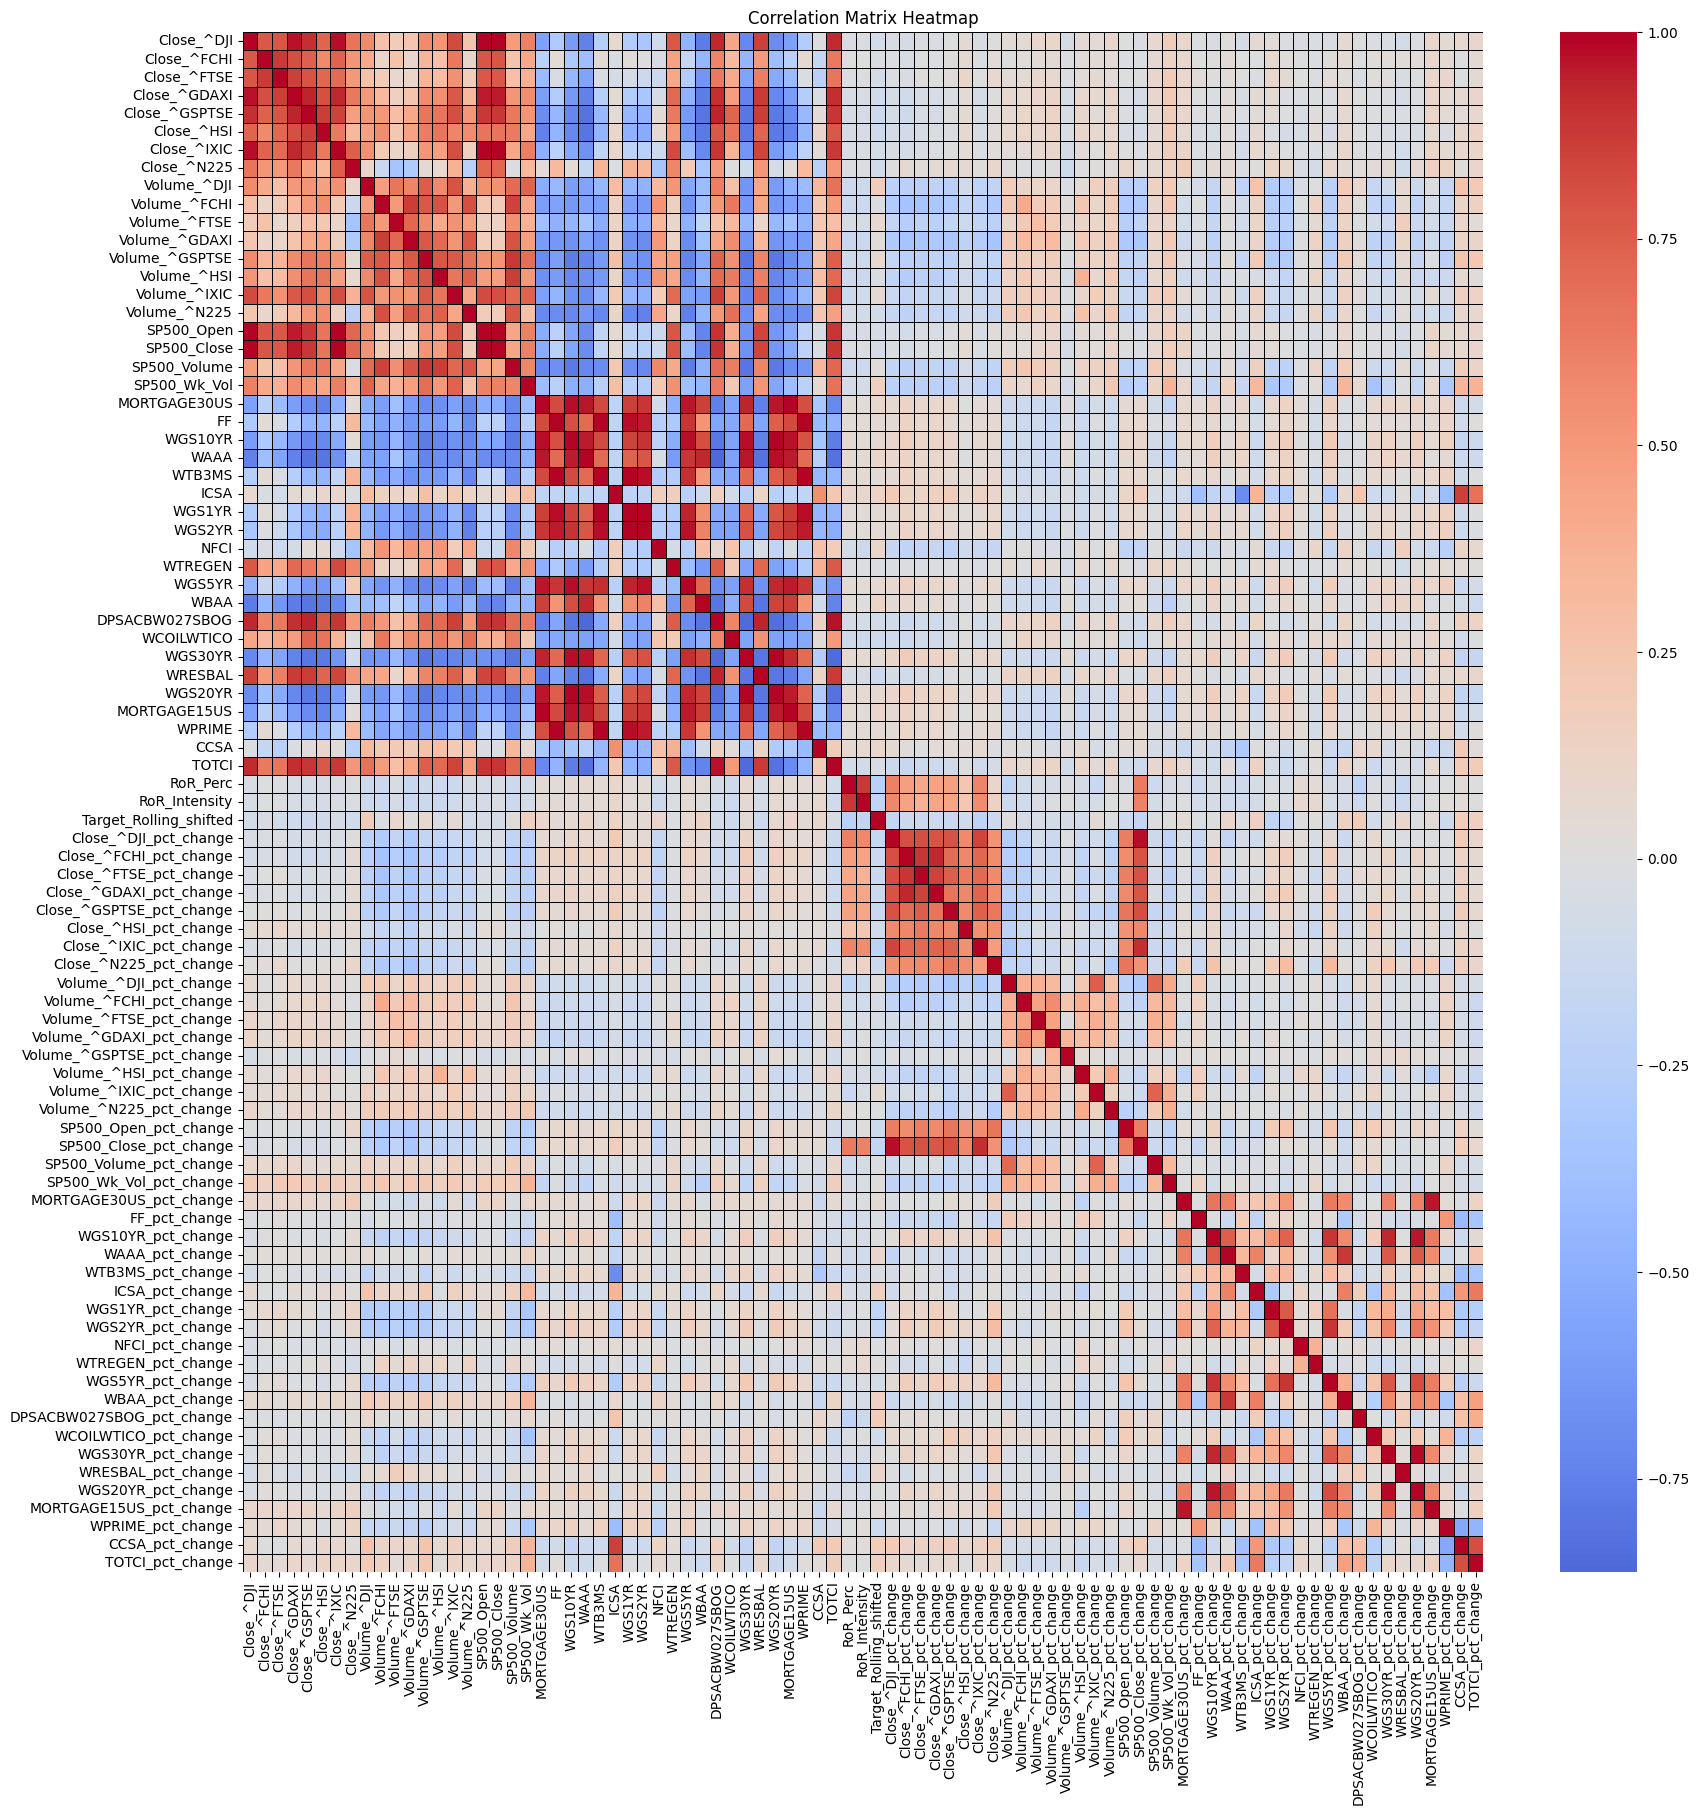

In [4]:
data_corr = data.corr()

plt.figure(figsize=(20, 20))
sns.heatmap(data_corr, annot=False, cmap='coolwarm', center=0, linewidths=0.5, linecolor='black')
plt.title('Correlation Matrix Heatmap')
plt.show()

# 2... Models

In [5]:
# Importing libraries
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

from keras.utils import to_categorical



## 2.1... Using original values

In [6]:
data_trial1 = data.iloc[:, list(range(0, 44))]
data_trial1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 258 entries, 1996-04-08 to 2015-02-02
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Close_^DJI              258 non-null    float64
 1   Close_^FCHI             258 non-null    float64
 2   Close_^FTSE             258 non-null    float64
 3   Close_^GDAXI            258 non-null    float64
 4   Close_^GSPTSE           258 non-null    float64
 5   Close_^HSI              258 non-null    float64
 6   Close_^IXIC             258 non-null    float64
 7   Close_^N225             258 non-null    float64
 8   Volume_^DJI             258 non-null    float64
 9   Volume_^FCHI            258 non-null    float64
 10  Volume_^FTSE            258 non-null    float64
 11  Volume_^GDAXI           258 non-null    float64
 12  Volume_^GSPTSE          258 non-null    float64
 13  Volume_^HSI             258 non-null    float64
 14  Volume_^IXIC            258 non

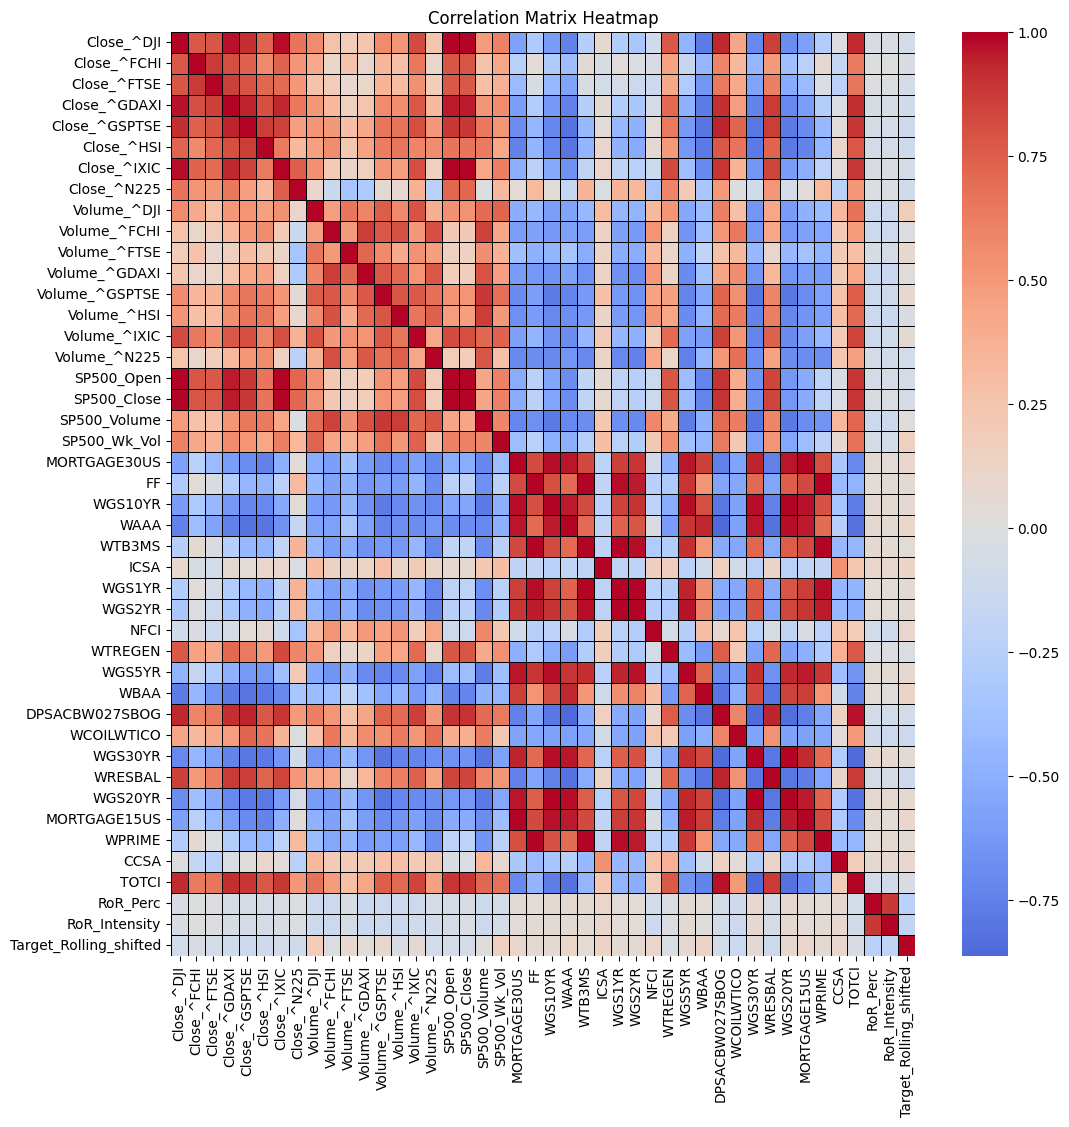

In [7]:
datat1_corr = data_trial1.corr()

plt.figure(figsize=(12, 12))
sns.heatmap(datat1_corr, annot=False, cmap='coolwarm', center=0, linewidths=0.5, linecolor='black')
plt.title('Correlation Matrix Heatmap')
plt.show()

We are going to evaluate 2 different target variables, the 5 label encoding for RoR Intensity week by week, and the binary classification for the high RoR summatory of the last 5 weeks (shifted to the start of the window).

### 2.1.1... RoR Rolling 5

#### Neural Network

In [8]:
data_trial1_2lab = data_trial1.drop(['SP500_Open', 'RoR_Perc', 'RoR_Intensity'], axis=1)

In [9]:
X2 = data_trial1_2lab.drop('Target_Rolling_shifted', axis=1)
y2 = data_trial1_2lab['Target_Rolling_shifted']

print(X2.shape)
print(y2.shape)

(258, 40)
(258,)


In [10]:
scaler2 = StandardScaler()

X2_scaled = scaler2.fit_transform(X2)

In [11]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2_scaled, y2, test_size = 0.3)
print(X2_train.shape, X2_test.shape, y2_train.shape, y2_test.shape)

(180, 40) (78, 40) (180,) (78,)


In [12]:
y2_train = to_categorical(y2_train)
y2_test = to_categorical(y2_test)

In [13]:
# Building the model
model2 = Sequential()

model2.add(Input(shape=(X2_train.shape[1],)))
model2.add(Dense(128, activation='relu'))
#model.add(Dropout(0.25))
model2.add(Dense(64, activation='relu'))
#model.add(Dropout(0.25))

model2.add(Dense(2, activation='softmax'))

In [14]:
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,634 (53.26 KB)

 Trainable params: 13,634 (53.26 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model2.compile(optimizer=Adam(learning_rate=0.001), loss='crossentropy', metrics=['accuracy', 'precision', 'recall'])

In [16]:
history2 = model2.fit(X2_train, y2_train, epochs=256, batch_size=256, verbose=1,
                      validation_data=(X2_test, y2_test))

Epoch 1/256
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5278 - loss: 0.7409 - precision: 0.5278 - recall: 0.5278 - val_accuracy: 0.7436 - val_loss: 0.6227 - val_precision: 0.7436 - val_recall: 0.7436
Epoch 2/256
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6222 - loss: 0.6524 - precision: 0.6222 - recall: 0.6222 - val_accuracy: 0.7949 - val_loss: 0.5309 - val_precision: 0.7949 - val_recall: 0.7949
Epoch 3/256
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7000 - loss: 0.5916 - precision: 0.7000 - recall: 0.7000 - val_accuracy: 0.8846 - val_loss: 0.4663 - val_precision: 0.8846 - val_recall: 0.8846
Epoch 4/256
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7944 - loss: 0.5535 - precision: 0.7944 - recall: 0.7944 - val_accuracy: 0.8846 - val_loss: 0.4228 - val_precision: 0.8846 - val_recall: 0.8846
Epoch 5/256
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8000 - loss: 0.5306 - precision: 0.8000 - recall: 0.8000 - val_accuracy: 0.8846 - val_loss: 0.3943 - val_p

In [17]:
# Evaluating the model on test data
test_loss, test_accuracy, test_precision, test_recall = model2.evaluate(X2_test, y2_test, verbose=1)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8023 - loss: 0.5994 - precision: 0.8023 - recall: 0.8023
Test Accuracy: 0.8077
Test Precision: 0.8077
Test Recall: 0.8077


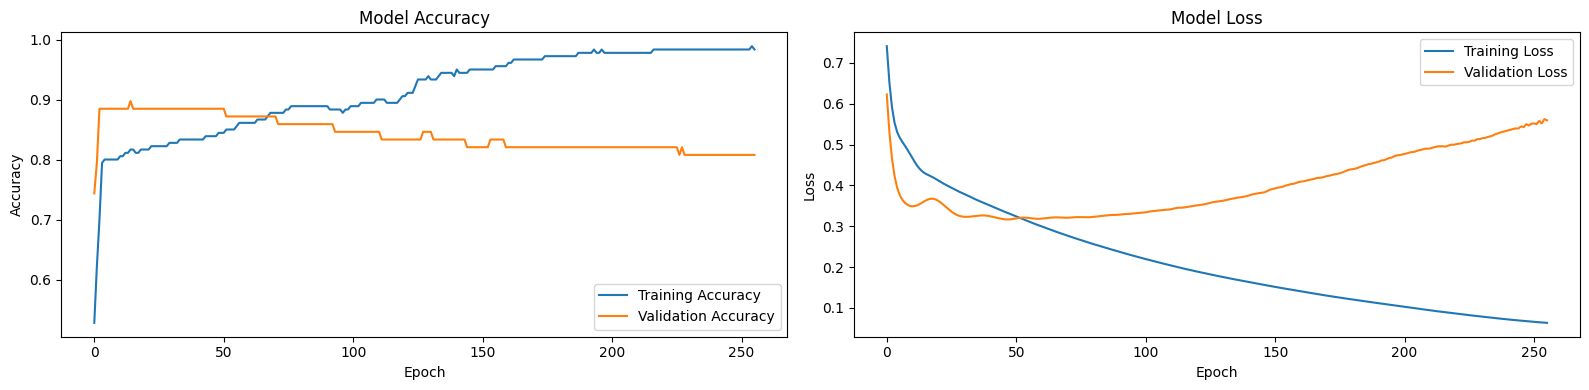

In [18]:
# Plotting training and validation accuracy values
plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plotting training and validation loss values
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

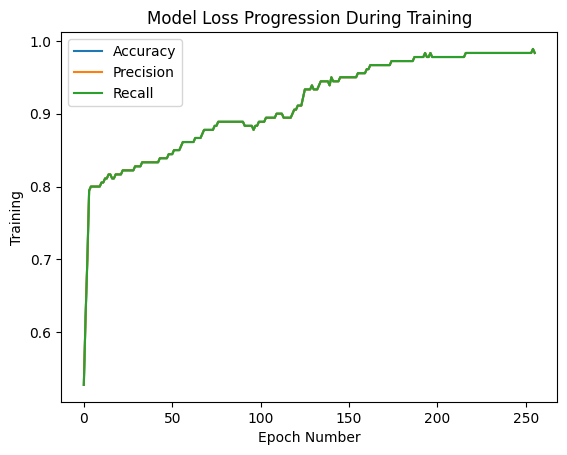

In [19]:
plt.plot(history2.history['accuracy'], label='Accuracy')
plt.plot(history2.history['precision'], label='Precision')
plt.plot(history2.history['recall'], label='Recall')

plt.title('Model Loss Progression During Training')
plt.ylabel('Training')
plt.xlabel('Epoch Number')
plt.legend(['Accuracy', 'Precision', 'Recall'])

#### Random Forest

In [20]:
# Convert to flattened categorical variable
y2_train_flat = np.argmax(y2_train, axis=1)
print(y2_train_flat)

y2_test_flat = np.argmax(y2_test, axis=1)

[0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 1 1 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 1 0 0 1 0 0 0 0 1 0 1 0 0 1 1 1 1 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0]


In [21]:
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=10)

rfc.fit(X2_train, y2_train_flat)

y_pred=rfc.predict(X2_test)

print("Accuracy:",metrics.accuracy_score(y2_test_flat, y_pred))
print("Precision:", metrics.precision_score(y2_test_flat, y_pred, average='weighted'))
print("Recall:", metrics.recall_score(y2_test_flat, y_pred, average='weighted'))

Accuracy: 0.8846153846153846
Precision: 0.8491902834008096
Recall: 0.8846153846153846


In [22]:
from sklearn.metrics import classification_report
print(classification_report(y2_test_flat, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94        69
           1       0.50      0.11      0.18         9

    accuracy                           0.88        78
   macro avg       0.70      0.55      0.56        78
weighted avg       0.85      0.88      0.85        78



<Axes: xlabel='Predicted', ylabel='Actual'>

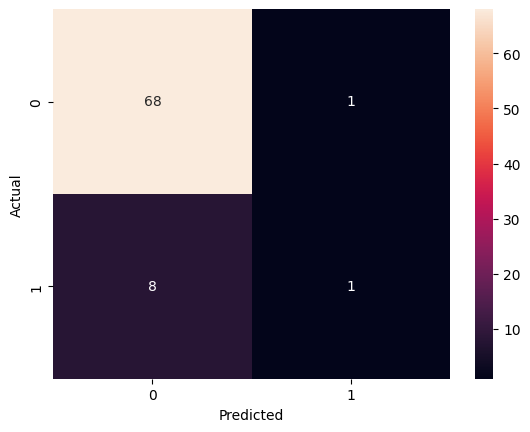

In [23]:
cm = pd.crosstab(y2_test_flat, y_pred, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(cm, annot=True)

#### XGB Classifier

In [24]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(n_estimators=10)

xgb_model.fit(X2_train, y2_train_flat)

y_pred1 = xgb_model.predict(X2_test)

print("Accuracy:", metrics.accuracy_score(y2_test_flat, y_pred1))
print("Precision:", metrics.precision_score(y2_test_flat, y_pred1, average='weighted'))
print("Recall:", metrics.recall_score(y2_test_flat, y_pred1, average='weighted'))

Accuracy: 0.8205128205128205
Precision: 0.8014239281844916
Recall: 0.8205128205128204


In [25]:
print(classification_report(y2_test_flat, y_pred1))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90        69
           1       0.14      0.11      0.12         9

    accuracy                           0.82        78
   macro avg       0.52      0.51      0.51        78
weighted avg       0.80      0.82      0.81        78



<Axes: xlabel='Predicted', ylabel='Actual'>

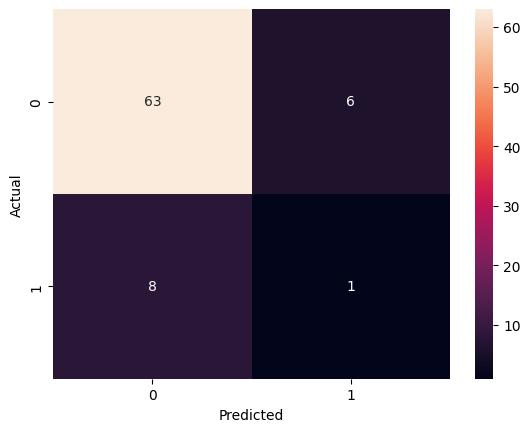

In [26]:
cm1 = pd.crosstab(y2_test_flat, y_pred1, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(cm1, annot=True)

#### SVM

In [27]:
from sklearn.svm import SVC

svm_model2 = SVC()

svm_model2.fit(X2_train, y2_train_flat)

y_pred2 = svm_model2.predict(X2_test)

print("Accuracy:", metrics.accuracy_score(y2_test_flat, y_pred2))
print("Precision:", metrics.precision_score(y2_test_flat, y_pred2, average='weighted'))
print("Recall:", metrics.recall_score(y2_test_flat, y_pred2, average='weighted'))

Accuracy: 0.8846153846153846
Precision: 0.7825443786982248
Recall: 0.8846153846153846


c:\Users\dange\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [28]:
print(classification_report(y2_test_flat, y_pred2))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94        69
           1       0.00      0.00      0.00         9

    accuracy                           0.88        78
   macro avg       0.44      0.50      0.47        78
weighted avg       0.78      0.88      0.83        78



c:\Users\dange\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dange\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dange\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

<Axes: xlabel='Predicted', ylabel='Actual'>

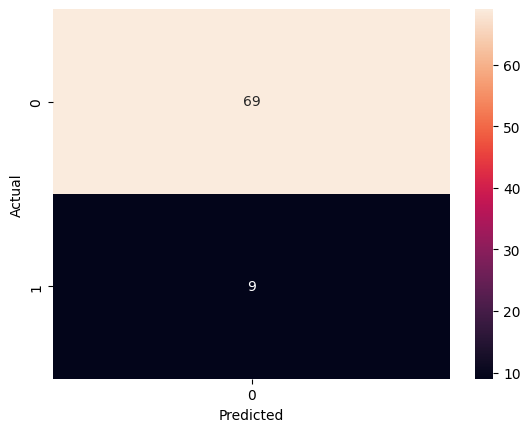

In [29]:
cm2 = pd.crosstab(y2_test_flat, y_pred2, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(cm2, annot=True)

### 2.1.2... RoR Intensity

#### Neural Network

In [30]:
data_trial1_5lab = data_trial1.drop(['SP500_Open', 'RoR_Perc', 'Target_Rolling_shifted'], axis=1)

In [31]:
X1 = data_trial1_5lab.drop('RoR_Intensity', axis=1)
y1 = data_trial1_5lab['RoR_Intensity']

print(X1.shape)
print(y1.shape)

(258, 40)
(258,)


In [32]:
scaler = StandardScaler()

X1_scaled = scaler.fit_transform(X1)

In [33]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1_scaled, y1, test_size = 0.3)
print(X1_train.shape, X1_test.shape, y1_train.shape, y1_test.shape)

(180, 40) (78, 40) (180,) (78,)


In [34]:
y1_train = to_categorical(y1_train)
y1_test = to_categorical(y1_test)

In [35]:
# Building the model
model = Sequential()

model.add(Input(shape=(X1_train.shape[1],)))
model.add(Dense(128, activation='relu'))
#model.add(Dropout(0.25))
model.add(Dense(64, activation='relu'))
#model.add(Dropout(0.25))

model.add(Dense(3, activation='softmax'))

In [36]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,699 (53.51 KB)

 Trainable params: 13,699 (53.51 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
model.compile(optimizer=Adam(learning_rate=0.00001), loss='crossentropy', metrics=['accuracy', 'precision', 'recall'])

In [38]:
history = model.fit(X1_train, y1_train, epochs=256, batch_size=256, verbose=1,
                      validation_data=(X1_test, y1_test))

Epoch 1/256
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3167 - loss: 1.1953 - precision: 0.3276 - recall: 0.1056 - val_accuracy: 0.3333 - val_loss: 1.2001 - val_precision: 0.3030 - val_recall: 0.1282
Epoch 2/256
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3167 - loss: 1.1946 - precision: 0.3276 - recall: 0.1056 - val_accuracy: 0.3333 - val_loss: 1.1994 - val_precision: 0.3030 - val_recall: 0.1282
Epoch 3/256
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3111 - loss: 1.1940 - precision: 0.3276 - recall: 0.1056 - val_accuracy: 0.3333 - val_loss: 1.1987 - val_precision: 0.3030 - val_recall: 0.1282
Epoch 4/256
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3111 - loss: 1.1933 - precision: 0.3276 - recall: 0.1056 - val_accuracy: 0.3333 - val_loss: 1.1980 - val_precision: 0.3030 - val_recall: 0.1282
Epoch 5/256
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3056 - loss: 1.1926 - precision: 0.3276 - recall: 0.1056 - val_accuracy: 0.3333 - val_loss: 1.1973 - val_p

In [39]:
# Evaluating the model on test data
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(X1_test, y1_test, verbose=1)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4445 - loss: 1.0713 - precision: 0.4812 - recall: 0.0608
Test Accuracy: 0.4359
Test Precision: 0.4000
Test Recall: 0.0513


In [40]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'precision', 'recall', 'val_accuracy', 'val_loss', 'val_precision', 'val_recall'])


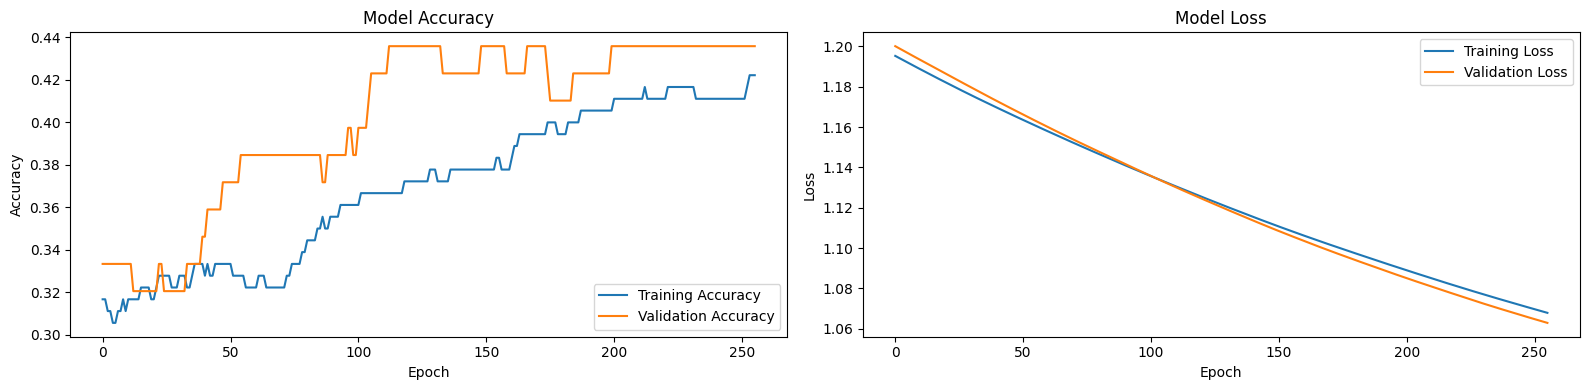

In [41]:
# Plotting training and validation accuracy values
plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plotting training and validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

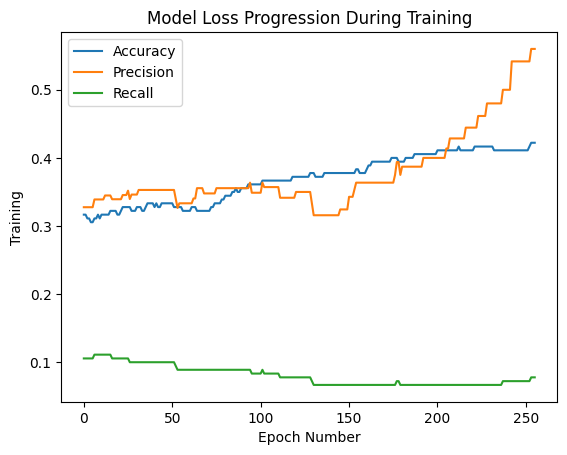

In [42]:
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['precision'], label='Precision')
plt.plot(history.history['recall'], label='Recall')

plt.title('Model Loss Progression During Training')
plt.ylabel('Training')
plt.xlabel('Epoch Number')
plt.legend(['Accuracy', 'Precision', 'Recall'])

#### Random Forrest

In [43]:
# Convert to flattened categorical variable
y1_train_flat = np.argmax(y1_train, axis=1)
print(y1_train_flat)

y1_test_flat = np.argmax(y1_test, axis=1)
print(y1_test_flat)

[2 0 0 0 2 1 2 2 0 2 2 0 2 2 0 0 1 1 2 0 1 1 2 1 1 0 2 2 1 0 1 0 2 0 2 1 2
 2 2 1 0 2 1 2 2 1 0 2 0 0 0 2 1 0 1 1 2 1 1 2 0 2 1 2 1 0 1 2 0 2 2 0 2 2
 0 2 2 0 0 0 1 2 2 2 1 1 0 2 1 2 1 0 1 0 1 2 2 0 0 2 0 2 0 2 1 2 2 1 2 1 0
 2 0 1 1 0 2 0 1 1 2 1 1 1 2 0 0 0 0 0 0 2 1 1 1 1 1 2 1 2 1 0 1 0 1 0 2 0
 1 1 2 0 0 2 2 0 1 1 2 1 1 1 2 2 2 0 0 2 0 0 2 2 0 1 0 2 1 1 0 1]
[2 1 2 1 2 0 0 0 2 0 1 0 0 1 1 1 1 1 0 2 1 1 0 1 0 2 2 1 2 0 0 1 2 1 2 0 1
 1 1 2 0 1 2 1 1 0 0 0 0 2 2 0 1 1 0 1 2 0 2 0 0 1 0 2 0 2 0 2 2 1 0 1 2 1
 1 0 0 0]


In [44]:
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=10)

rfc.fit(X1_train, y1_train_flat)

y_pred3=rfc.predict(X1_test)

print("Accuracy:",metrics.accuracy_score(y1_test_flat, y_pred3))
print("Precision:", metrics.precision_score(y1_test_flat, y_pred3, average='weighted'))
print("Recall:", metrics.recall_score(y1_test_flat, y_pred3, average='weighted'))

Accuracy: 0.5
Precision: 0.5103550295857988
Recall: 0.5


In [45]:
from sklearn.metrics import classification_report
print(classification_report(y1_test_flat, y_pred3))

              precision    recall  f1-score   support

           0       0.50      0.48      0.49        29
           1       0.65      0.61      0.63        28
           2       0.33      0.38      0.36        21

    accuracy                           0.50        78
   macro avg       0.50      0.49      0.49        78
weighted avg       0.51      0.50      0.50        78



<Axes: xlabel='Predicted', ylabel='Actual'>

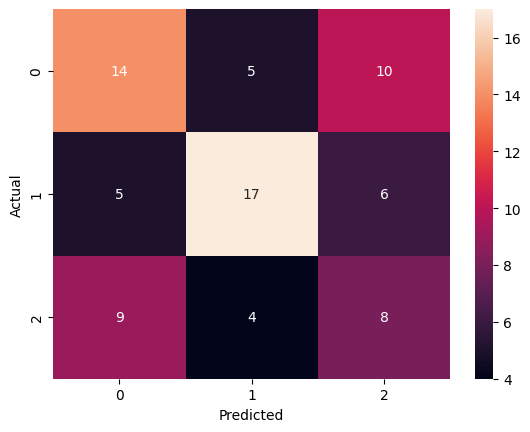

In [46]:
from sklearn.metrics import confusion_matrix
cm3 = pd.crosstab(y1_test_flat, y_pred3, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(cm3, annot=True)

#### XGB Classifier


In [47]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(n_estimators=10)

xgb_model.fit(X1_train, y1_train_flat)

y_pred4 = xgb_model.predict(X1_test)

print("Accuracy:", metrics.accuracy_score(y1_test_flat, y_pred4))
print("Precision:", metrics.precision_score(y1_test_flat, y_pred4, average='weighted'))
print("Recall:", metrics.recall_score(y1_test_flat, y_pred4, average='weighted'))


Accuracy: 0.5512820512820513
Precision: 0.5898892773892774
Recall: 0.5512820512820513


In [48]:
print(classification_report(y1_test_flat, y_pred4))

              precision    recall  f1-score   support

           0       0.59      0.45      0.51        29
           1       0.75      0.64      0.69        28
           2       0.38      0.57      0.45        21

    accuracy                           0.55        78
   macro avg       0.57      0.55      0.55        78
weighted avg       0.59      0.55      0.56        78



<Axes: xlabel='Predicted', ylabel='Actual'>

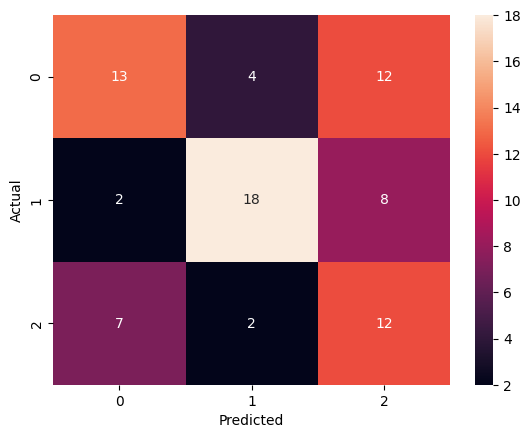

In [49]:
cm4 = pd.crosstab(y1_test_flat, y_pred4, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(cm4, annot=True)

#### SVM

In [50]:
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(X1_train, y1_train_flat)

y_pred5 = svm_model.predict(X1_test)

print("Accuracy:", metrics.accuracy_score(y1_test_flat, y_pred5))
print("Precision:", metrics.precision_score(y1_test_flat, y_pred5, average='weighted'))
print("Recall:", metrics.recall_score(y1_test_flat, y_pred5, average='weighted'))


Accuracy: 0.5384615384615384
Precision: 0.6104353011329755
Recall: 0.5384615384615384


In [51]:
print(classification_report(y1_test_flat, y_pred5))

              precision    recall  f1-score   support

           0       0.60      0.21      0.31        29
           1       0.80      0.71      0.75        28
           2       0.37      0.76      0.50        21

    accuracy                           0.54        78
   macro avg       0.59      0.56      0.52        78
weighted avg       0.61      0.54      0.52        78



<Axes: xlabel='Predicted', ylabel='Actual'>

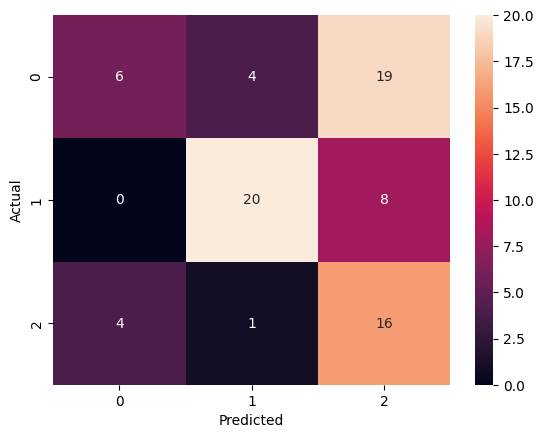

In [52]:
cm5 = pd.crosstab(y1_test_flat, y_pred5, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(cm5, annot=True)